# 02 · Replication: can unsupervised clustering recover expert coda types?

**Question.** Without seeing the labels, does a clustering method recover the coda types defined by experts for the EC1 clan?

**Why start here.** The coda types are already known, so this experiment *validates the pipeline*. If it cannot recover known structure, nothing it finds later would be trustworthy. Where it disagrees with the experts, the disagreement is itself the interesting result.

**Protocol (fixed before looking at results):**

1. Data: EC1 clan, `*-NOISE` removed, ≥ 3 clicks (see notebook 01).
2. Cluster **separately within each click count** (click count is directly observable).
3. Gaussian Mixture Models; number of clusters chosen by **BIC**, never by the labels.
4. Compare three feature sets: `rhythm`, `rhythm+tempo`, `raw` ICIs.
5. Evaluate against expert labels with ARI, NMI, **homogeneity** and **completeness**.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from whalecodas import load_codas, filter_codas, cluster_by_click_count, evaluate, seed_stability, rhythm_matrix
from whalecodas.data import PROJECT_ROOT
FIG = PROJECT_ROOT / "reports" / "figures"
sns.set_theme(style="whitegrid", context="notebook")

df = filter_codas(load_codas())
y = df.CodaType.to_numpy()
print(f"{len(df)} codas, {df.CodaType.nunique()} expert types")

7268 codas, 24 expert types


### How to read the metrics

| metric | = 1 when… | not penalised |
|---|---|---|
| **homogeneity** | each cluster contains a single expert type | splitting a type into several clusters |
| **completeness** | each expert type falls in a single cluster | merging several types into one cluster |
| **NMI** | both of the above (harmonic mean) | – |
| **ARI** | pairwise agreement, chance-corrected | – |

High homogeneity with lower completeness means the algorithm finds groups **finer** than the expert labels.

## 1. Baseline comparison of feature sets

In [2]:
results, labels_by_kind, summaries = [], {}, {}
for kind in ["rhythm", "rhythm+tempo", "raw"]:
    labels, summary = cluster_by_click_count(df, kind=kind)
    labels_by_kind[kind], summaries[kind] = labels, summary
    results.append({"features": kind, **evaluate(y, labels)})
pd.DataFrame(results).set_index("features").round(3)

,ARI,NMI,homogeneity,completeness,n_clusters,n_types
features,,,,,,
rhythm,0.427,0.711,0.844,0.614,28,24
rhythm+tempo,0.487,0.792,0.956,0.676,34,24
raw,0.478,0.790,0.950,0.676,36,24


Per click count (feature set `rhythm+tempo`):

In [3]:
rows = []
L = labels_by_kind["rhythm+tempo"]
for s in summaries["rhythm+tempo"]:
    m = df.nClicks.to_numpy() == s.n_clicks
    e = evaluate(y[m], L[m])
    rows.append({"clicks": s.n_clicks, "codas": s.n_codas, "expert types": e["n_types"],
                 "clusters (BIC)": s.k_selected, "homogeneity": e["homogeneity"],
                 "completeness": e["completeness"], "ARI": e["ARI"]})
per_group = pd.DataFrame(rows).set_index("clicks").round(2)
per_group

,codas,expert types,clusters (BIC),homogeneity,completeness,ARI
clicks,,,,,,
3,82,2,2,0.85,0.82,0.90
4,726,5,5,0.84,0.80,0.86
5,5467,5,8,0.95,0.46,0.39
6,185,2,2,0.19,0.02,0.02
7,351,3,5,0.80,0.51,0.54
8,239,3,4,0.68,0.39,0.39
9,155,2,2,0.20,0.12,-0.00
10,63,2,6,0.71,0.22,0.20


**Reading:** adding tempo to rhythm raises homogeneity substantially: clusters become almost pure. Completeness stays lower because BIC tends to choose **more** clusters than there are expert types. The next section looks at where those extra clusters come from.

Note: ARI can be undefined or ≈ 0 in groups where one type dominates (e.g. 6 clicks: 182 × `6i` vs 3 × `6R`), so per-group ARI should be read with the group composition in mind.

## 2. Where do clusters and experts disagree? (5-click codas)

In [4]:
five = df.nClicks.to_numpy() == 5
tab = pd.crosstab(pd.Series(L[five], name="cluster"), pd.Series(y[five], name="expert type"))
tab["mean duration (s)"] = df[five].groupby(L[five]).Duration.mean().round(2)
tab.sort_values("mean duration (s)")

expert type,1+1+3,2+3,5R1,5R2,5R3,mean duration (s)
cluster,,,,,,
5_0,0,0,804,0,0,0.32
5_5,0,0,303,0,0,0.33
5_7,0,0,354,0,0,0.34
5_2,1,0,49,287,17,0.51
5_4,0,77,0,0,0,0.65
5_6,468,0,0,0,2,0.80
5_3,1413,0,0,0,0,0.94
5_1,1692,0,0,0,0,1.26


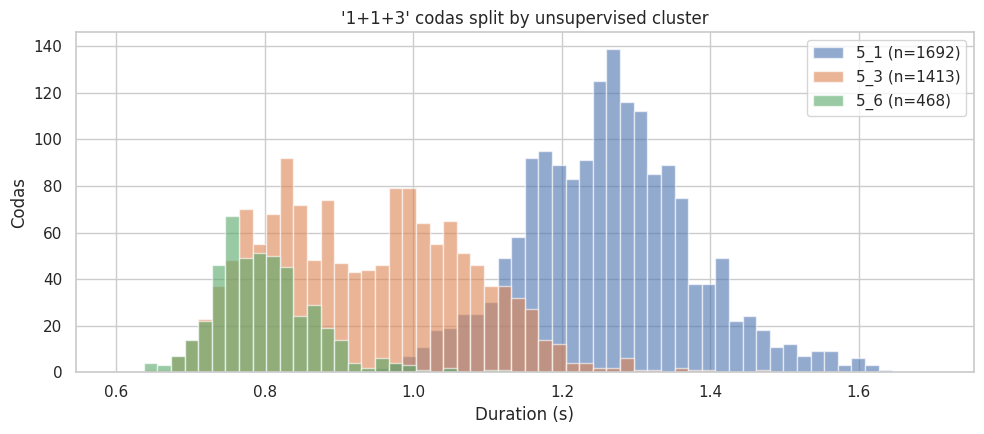

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sub = df[five].assign(cluster=L[five])
sub = sub[sub.CodaType == "1+1+3"]
for c, g in sub.groupby("cluster"):
    if len(g) > 50:
        ax.hist(g.Duration, bins=60, range=(0.6, 1.7), alpha=.6, label=f"{c} (n={len(g)})")
ax.set(title="'1+1+3' codas split by unsupervised cluster", xlabel="Duration (s)", ylabel="Codas")
ax.legend(); plt.tight_layout(); plt.savefig(FIG / "02_113_split.png", dpi=150); plt.show()

**What the table shows.** The disagreements with the experts are of three kinds:

- **Split by tempo**: `1+1+3` is divided into pure sub-groups with clearly different mean durations, matching the modes seen in notebook 01.
- **Split without tempo difference**: `5R1` is divided into three clusters with the *same* mean duration (~0.33 s). These differ in fine rhythm, not speed. Whether this is meaningful (e.g. rubato, individual style) or just the GMM carving a continuous cloud is an open question.
- **Merge**: one cluster combines `5R2`, almost all `5R3` (only 17–19 in EC1) and a few `5R1`. With so few `5R3` codas in EC1, the model cannot justify a separate component.

The tempo split of `1+1+3` is the most interesting disagreement because it is consistent with Sharma et al. (2024), who describe tempo as a discrete feature combined with rhythm. But a pattern visible in one run is not yet a result; sections 3–5 test it.

## 3. Sanity check: is the tempo split a trivial artefact?

If each tempo sub-group came from a different social unit or a different recording year, the split would reflect *who/when was recorded* rather than a property of the codas. Check how the sub-groups distribute across units and years.

In [6]:
from sklearn.metrics import normalized_mutual_info_score as nmi
big = sub.groupby("cluster").filter(lambda g: len(g) > 50)
print("NMI(cluster, social unit):", round(nmi(big.cluster, big.Unit), 3))
print("NMI(cluster, year):       ", round(nmi(big.cluster, big.Date.dt.year), 3))
prop = pd.crosstab(big.Unit, big.cluster, normalize="index").round(2)
prop["n"] = big.Unit.value_counts()
prop.sort_values("n", ascending=False)

NMI(cluster, social unit): 0.051
NMI(cluster, year):        0.051


cluster,5_1,5_3,5_6,n
Unit,,,,
A,0.33,0.51,0.16,852
J,0.42,0.49,0.09,730
U,0.70,0.20,0.09,668
F,0.60,0.23,0.16,626
S,0.77,0.18,0.05,167
R,0.28,0.58,0.15,156
V,0.35,0.58,0.07,137
D,0.15,0.64,0.20,104
N,0.22,0.43,0.35,69


Every social unit produces codas in every tempo sub-group, and the association with unit or year is weak. The split is **not** explained by recording context. Units do show different *preferences* (some favour faster, others slower `1+1+3`), which is itself a question worth following up.

Caveat: ~2/3 of codas have no identified whale, so we cannot yet rule out that individual whales specialise in one tempo.

## 4. Robustness: stability across random seeds

GMMs depend on initialisation. Re-run the whole pipeline with different seeds and compare against seed 0.

In [7]:
stab = seed_stability(df, n_seeds=5, kind="rhythm+tempo")
print("ARI vs seed 0:", stab.round(2), "  mean =", stab.mean().round(2))
k_by_seed = pd.DataFrame({s: {g.n_clicks: g.k_selected for g in cluster_by_click_count(df, seed=s)[1]} for s in range(5)})
k_by_seed.index.name = "clicks"; k_by_seed.columns.name = "seed"
k_by_seed

ARI vs seed 0: [0.68 0.74 0.76 0.77]   mean = 0.74


seed,0,1,2,3,4
clicks,,,,,
3,2,2,2,2,2
4,5,6,5,5,5
5,8,8,8,8,8
6,2,2,2,2,2
7,5,5,4,5,5
8,4,4,3,4,3
9,2,2,2,2,2
10,6,6,4,5,1


Agreement between seeds is only moderate. The number of clusters is unstable in the small groups (8 and 10 clicks), but in the 5-click group k = 8 in every run, so the instability there must come from *where the boundaries fall*. Check stability per group and within the two big types:

In [8]:
from sklearn.metrics import adjusted_rand_score as ari
runs = [cluster_by_click_count(df, seed=s)[0] for s in range(5)]
rows = {}
for name, mask in {"5 clicks (all)": df.nClicks.to_numpy() == 5,
                   "1+1+3 only": (df.CodaType == "1+1+3").to_numpy(),
                   "5R1 only": (df.CodaType == "5R1").to_numpy()}.items():
    rows[name] = [ari(runs[0][mask], r[mask]) for r in runs[1:]]
pd.DataFrame(rows, index=[f"seed {s}" for s in range(1, 5)]).T.round(2)

,seed 1,seed 2,seed 3,seed 4
5 clicks (all),0.63,0.71,0.73,0.74
1+1+3 only,0.53,0.58,0.61,0.61
5R1 only,0.49,0.85,0.85,0.96


**Honest limitation.** Inside `1+1+3` the partition changes noticeably from seed to seed (ARI ≈ 0.5–0.6). The full 5-dimensional model finds *that* `1+1+3` should be split, but not reliably *where*. On its own, this run would not support a claim about tempo classes.

## 5. A focused test: how many tempo classes does `1+1+3` have?

Instead of the full rhythm+tempo model, ask the precise question directly: fit 1-D Gaussian mixtures to **log(duration)** of `1+1+3` codas only, choose k by BIC, and check robustness across seeds and bootstrap resamples.

In [9]:
from sklearn.mixture import GaussianMixture
x = np.log(df.loc[df.CodaType == "1+1+3", "Duration"].to_numpy())[:, None]

def best_k(data, seed=0, k_max=6):
    bics = [GaussianMixture(k, random_state=seed, n_init=5).fit(data).bic(data) for k in range(1, k_max + 1)]
    return int(np.argmin(bics)) + 1, np.array(bics) - min(bics)

k0, dbic = best_k(x)
print("Selected k:", k0)
print("ΔBIC vs best for k = 1..6:", dbic.round(0))

print("k by seed:", [best_k(x, seed=s)[0] for s in range(5)])

rng = np.random.default_rng(0)
boot = [best_k(x[rng.integers(0, len(x), len(x))], k_max=5)[0] for _ in range(30)]
print("k over 30 bootstrap resamples:", dict(zip(*np.unique(boot, return_counts=True))))

g = GaussianMixture(3, random_state=0, n_init=5).fit(x)
print("Class centres (s):", np.sort(np.exp(g.means_.ravel())).round(2))
part = [GaussianMixture(3, random_state=s, n_init=5).fit_predict(x) for s in range(5)]
print("Partition ARI vs seed 0:", [round(ari(part[0], p), 2) for p in part[1:]])

Selected k: 3
ΔBIC vs best for k = 1..6: [922. 109.   0.  33.  48.  39.]


k by seed: [3, 3, 3, 3, 3]


k over 30 bootstrap resamples: {np.int64(3): np.int64(30)}
Class centres (s): [0.81 1.05 1.28]
Partition ARI vs seed 0: [1.0, 1.0, 1.0, 1.0]


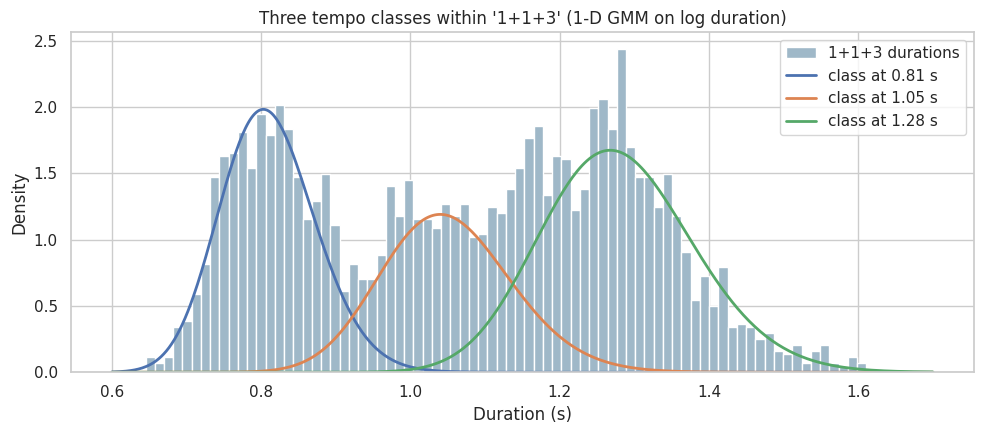

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.5))
dur = np.exp(x.ravel())
ax.hist(dur, bins=80, density=True, color="#9fb8c8", label="1+1+3 durations")
grid = np.linspace(np.log(0.6), np.log(1.7), 400)[:, None]
for w, mu, var in sorted(zip(g.weights_, g.means_.ravel(), g.covariances_.ravel()), key=lambda t: t[1]):
    pdf_log = w * np.exp(-(grid.ravel() - mu) ** 2 / (2 * var)) / np.sqrt(2 * np.pi * var)
    ax.plot(np.exp(grid.ravel()), pdf_log / np.exp(grid.ravel()), lw=2, label=f"class at {np.exp(mu):.2f} s")
ax.set(title="Three tempo classes within '1+1+3' (1-D GMM on log duration)", xlabel="Duration (s)", ylabel="Density")
ax.legend(); plt.tight_layout(); plt.savefig(FIG / "02_113_tempo_classes.png", dpi=150); plt.show()

**Result.** The focused model selects **k = 3 in every seed and in 30/30 bootstrap resamples**, with centres at about **0.81 s, 1.05 s and 1.28 s**, and the partition is identical across seeds. BIC prefers 3 classes clearly over 2 and over 4.

**Methodological lesson.** The multi-dimensional model *signalled* the structure but blurred it; the targeted test *confirmed* it cleanly. Discovery and confirmation are different steps and deserve different tools.

## Summary

| | result |
|---|---|
| Best feature set | rhythm + tempo |
| Homogeneity | ≈ 0.96 → clusters are almost pure |
| Completeness | ≈ 0.68 → clusters are finer than expert types |
| Main disagreement | `1+1+3` split by tempo, consistent with Sharma et al. (2024) |
| Confound check | split not explained by social unit or year |
| Stability (full model) | moderate; boundaries inside `1+1+3` move between seeds |
| Focused test | `1+1+3` has **3 tempo classes** (~0.81 / 1.05 / 1.28 s), stable in 5/5 seeds and 30/30 bootstraps |

## Next steps

1. **Shared tempo classes?** Fit the same 1-D test to every rhythm type and check whether the tempo centres line up across types (Sharma et al. report a small set of shared tempo types).
2. **The `5R1` split**: three clusters with the same duration. Is it stable, and does it relate to rubato, social unit, or individual whales?
3. **Unit preferences**: test whether social units differ in tempo usage, accounting for non-independence (codas are nested in recordings and whales).
4. **EC2 clan** (949 codas) as an out-of-sample check of the whole pipeline.
5. **Model selection**: compare BIC with HDBSCAN and consensus clustering for the full model.